# 1. Подготовка датасета

## 1.1. Выбор и установка датасета

В качестве датасета берём, как и предлагалось, датасет [CelebA](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). Работать будем с его некропнутой версией In-The-Wild Images. Датасет установлен архивом CelebA.zip, нужная версия датасета лежит в архиве

P.S. Данный ноутбук выполнялся локально. Все ноутбуки с непосредственным обучением моделей будут выполняться на Kaggle. Так же все папки связанные с исходным датасетом (200к картинок) не загружены на гит, загружен уже только оставленный после выборки датасет

In [2]:
!unzip CelebA.zip -d CelebA

Archive:  CelebA.zip
   creating: CelebA/CelebA/
   creating: CelebA/CelebA/Anno/
  inflating: CelebA/CelebA/Anno/identity_CelebA.txt  
  inflating: CelebA/CelebA/Anno/list_attr_celeba.txt  
  inflating: CelebA/CelebA/Anno/list_bbox_celeba.txt  
  inflating: CelebA/CelebA/Anno/list_landmarks_align_celeba.txt  
  inflating: CelebA/CelebA/Anno/list_landmarks_celeba.txt  
   creating: CelebA/CelebA/Eval/
  inflating: CelebA/CelebA/Eval/list_eval_partition.txt  
   creating: CelebA/CelebA/Img/
  inflating: CelebA/CelebA/Img/img_align_celeba.zip  
   creating: CelebA/CelebA/Img/img_align_celeba_png.7z/
  inflating: CelebA/CelebA/Img/img_align_celeba_png.7z/img_align_celeba_png.7z.001  
  inflating: CelebA/CelebA/Img/img_align_celeba_png.7z/img_align_celeba_png.7z.002  
  inflating: CelebA/CelebA/Img/img_align_celeba_png.7z/img_align_celeba_png.7z.003  
  inflating: CelebA/CelebA/Img/img_align_celeba_png.7z/img_align_celeba_png.7z.004  
  inflating: CelebA/CelebA/Img/img_align_celeba_png.7z/

Согласно файлу README.txt нужная версия датасета лежит в архиве img_celeba.7z. Здесь можно наблюдать страдания человека который снёс линукс недавно. (с unzip повезло, он был в Git for Windows)

In [7]:
!"C:\Program Files\7-Zip\7z.exe" x "CelebA/CelebA/Img/img_celeba.7z" -o"CelebA/CelebA/Img/img_celeba" -y


7-Zip 24.09 (x64) : Copyright (c) 1999-2024 Igor Pavlov : 2024-11-29

Scanning the drive for archives:
1 folder, 14 files, 10191072466 bytes (9719 MiB)

Extracting archive: CelebA\CelebA\Img\img_celeba.7z\img_celeba.7z.001
--
Path = CelebA\CelebA\Img\img_celeba.7z\img_celeba.7z.001
Type = Split
Physical Size = 734003200
Volumes = 14
Total Physical Size = 10191072466
----
Path = img_celeba.7z
Size = 10191072466
--
Path = img_celeba.7z
Type = 7z
Physical Size = 10191072466
Headers Size = 1963891
Method = LZMA:24
Solid = +
Blocks = 5

Everything is Ok

Folders: 1
Files: 202599
Size:       10497242009
Compressed: 10191072466


## 1.2. Обзор датасета

Сначала посмотрим на примеры фотографий в датасете

In [1]:
import os
import shutil
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


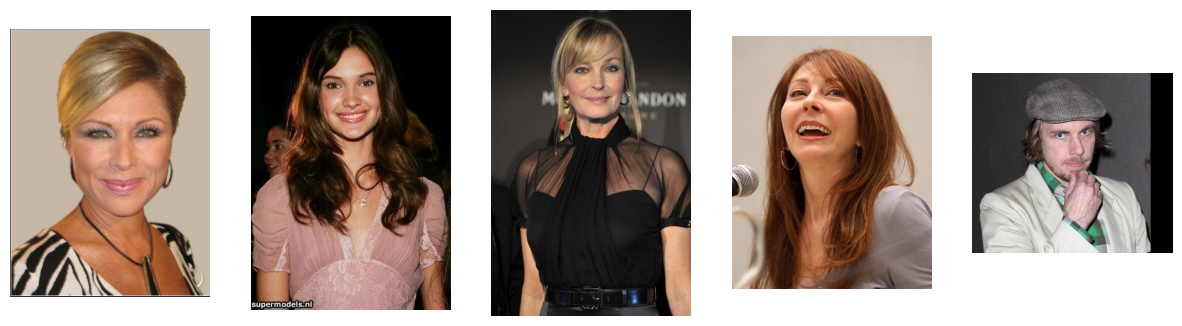

In [4]:
folder = 'CelebA/CelebA/Img/img_celeba/img_celeba'
images = os.listdir(folder)
random_indices = np.random.choice(len(images), 5, replace=False)
random_images = [images[i] for i in random_indices]

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, img_name in enumerate(random_images):
    img = mpimg.imread(os.path.join(folder, img_name))
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show()

Файл list_attr_celeba.txt содержит аттрибуты каждого изображения. Загрузим его как padnas dataframe и посмотрим на него

In [5]:
attr = pd.read_csv('CelebA/CelebA/Anno/list_attr_celeba.txt', skiprows=1, sep=r'\s+')
for column in attr.columns:
  attr[column] = (attr[column] + 1) // 2 # [-1; 1] -> [0; 1]
attr.index.name = 'image_id'
attr.head()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


Так же загрузим другие вспомогательные файлы, объеденим всё в один dataframe.
- identity_CelebA.txt - хранит id для каждого изображения. Одинаковое id = одна и та же личность. Это и будет наша целевая переменная.
- list_bbox_celeba.txt - координаты bounding box'a лица.
- list_landmarks_celeba.txt - координаты ключевых точек лица.

In [6]:
identity = pd.read_csv('CelebA/CelebA/Anno/identity_CelebA.txt', names=['image_id', 'person'], index_col=0, sep=r'\s+')
bbox = pd.read_csv('CelebA/CelebA/Anno/list_bbox_celeba.txt', skiprows=1, index_col=0, sep=r'\s+')
landmarks = pd.read_csv('CelebA/CelebA/Anno/list_landmarks_celeba.txt', skiprows=1, index_col=0, sep=r'\s+')
landmarks.index.name = 'image_id'

df = pd.concat([attr, bbox, landmarks, identity], axis=1)
df.head()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y,person
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,184,244,176,196,249,194,271,266,260,2880
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,204,220,204,168,254,146,289,226,289,2937
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,104,264,105,263,121,235,134,251,140,8692
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,539,984,539,930,687,762,756,915,756,5805
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,169,328,161,298,172,283,208,323,207,9295


In [7]:
df.columns

Index(['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
       'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
       'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
       'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
       'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
       'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
       'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
       'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
       'Wearing_Necklace', 'Wearing_Necktie', 'Young', 'x_1', 'y_1', 'width',
       'height', 'lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y',
       'nose_x', 'nose_y', 'leftmouth_x', 'leftmouth_y', 'rightmouth_x',
       'rightmouth_y', 'person'],
      dtype='str')

## 1.3. Отбор датасета

Займёмся теперь тем, что у нас 200к фотографий, но нам не нужно так много - мы будем работать с 10к+ фотографиями. В списке аттрибутов есть параметр Blurry, отвечающий за размытость изображения. Возьмём изображения без размытия. Так же возьмём людей, которые не носят очки/шапки, т.к. очень часто это воспринимается как шум.

In [8]:
df_not_noisy = df[(df['Blurry'] == 0) & (df['Eyeglasses'] == 0) & (df['Wearing_Hat'] == 0)]
len(df_not_noisy)

172107

Мы хотим баланс классов - т.е. мы хотим чтобы на каждого человека которого мы оставим было одинаковое число фотографий. Например мы хотим сделать 1000 людей по 15 фотографий (15к изображений). Отберём для начала только людей, для которых найдётся по 15 фотографий хотя бы.

UPD: Такой выбор оказался очень плохим и не обучил сеть. Поэтому теперь мы пробуем новую стратегию. Заметим, что если мы отберём по 30 фотографий, то у нас 18к изображений, а с 31 уже всего лишь 164. Поэтому новая стратегия будет такой: Отбираем 350 человек по 30+ фотографий. Т.к. с 36 фотографиями уже никого нет, то верхнюю границу не ставим

In [29]:
person_counts = df_not_noisy['person'].value_counts()
valid_ids = person_counts[person_counts >= 36].index
df_limited = df_not_noisy[df_not_noisy['person'].isin(valid_ids)]
len(df_limited)

0

In [30]:
person_counts = df_not_noisy['person'].value_counts()
valid_ids = person_counts[person_counts >= 31].index
df_limited = df_not_noisy[df_not_noisy['person'].isin(valid_ids)]
len(df_limited)

164

In [31]:
person_counts = df_not_noisy['person'].value_counts()
valid_ids = person_counts[person_counts >= 30].index
df_limited = df_not_noisy[df_not_noisy['person'].isin(valid_ids)]
len(df_limited)

18374

Возьмём для удобства DF где присутствует лишь 1 фотография каждого человека.

In [32]:
df_one_per_person = df_limited.groupby('person').first()
len(df_one_per_person)

612

Теперь сделаем следующее. Хотим отобрать суммарно около 800 людей (по ~15 фотографий на каждого). Возьмём, пройдёмся по каждому атрибуту, взяв 70 человек С этим атрибутом и 70 человек БЕЗ него. (70 с учётом пересечений. Подбиралось чтобы было примерно 800 людей)

UPD: Поставив задачу на 350 человек, у нас поменялись параметры. 350 человек, 30-35 фотографий на одного - получили вместо числа 70 число 50

In [37]:
attributes = attr.columns.tolist()
attributes.remove('Blurry')
attributes.remove('Eyeglasses')
attributes.remove('Wearing_Hat')

selected_people = set()

for attribute in attributes:
    pos = df_one_per_person[df_one_per_person[attribute] == 1].index
    neg = df_one_per_person[df_one_per_person[attribute] == -1].index
    pos_selected = set(pos[:50]) if len(pos) >= 50 else set(pos)
    neg_selected = set(neg[:50]) if len(neg) >= 50 else set(neg)
    
    selected_people.update(pos_selected)
    selected_people.update(neg_selected)
  
selected_people = list(selected_people)

df_diversity = df_one_per_person.loc[selected_people]
len(df_diversity)

355

Теперь возьмём id выбранных людей и возьмём для каждого $max(n, 20)$ фотографий, где n - всего фотографий на человека и $n >= 15$

UPD: Здесь чтобы не переписывать код, просто поменял границы [15; 20] на [30; 35]

In [38]:
ids = df_diversity.index
df_filtered = df_limited[df_limited['person'].isin(ids)]

def reduce_photos(group):
    if len(group) > 35:
        return group.sample(35, random_state=42)
    else:
        return group
df_filtered = df_filtered.groupby('person', group_keys=False).apply(reduce_photos)
df_filtered = df_filtered.join(identity, how='left')
len(df_filtered)

10662

На всякий случай убедимся в проделанном. Напомню что для атрибутов мы требовали чтобы каждый из них встречался, а не баланс.

In [39]:
df_filtered.groupby('person').size()

person
14       30
23       30
32       30
59       30
65       30
         ..
10036    30
10044    30
10062    30
10108    30
10156    30
Length: 355, dtype: int64

In [40]:
for attribute in attributes:
    print(df_filtered[attribute].value_counts(), '\n')

5_o_Clock_Shadow
0    9319
1    1343
Name: count, dtype: int64 

Arched_Eyebrows
0    5459
1    5203
Name: count, dtype: int64 

Attractive
1    7426
0    3236
Name: count, dtype: int64 

Bags_Under_Eyes
0    7882
1    2780
Name: count, dtype: int64 

Bald
0    10591
1       71
Name: count, dtype: int64 

Bangs
0    8496
1    2166
Name: count, dtype: int64 

Big_Lips
0    7689
1    2973
Name: count, dtype: int64 

Big_Nose
0    7945
1    2717
Name: count, dtype: int64 

Black_Hair
0    8563
1    2099
Name: count, dtype: int64 

Blond_Hair
0    8404
1    2258
Name: count, dtype: int64 

Brown_Hair
0    8105
1    2557
Name: count, dtype: int64 

Bushy_Eyebrows
0    9060
1    1602
Name: count, dtype: int64 

Chubby
0    10447
1      215
Name: count, dtype: int64 

Double_Chin
0    10457
1      205
Name: count, dtype: int64 

Goatee
0    10226
1      436
Name: count, dtype: int64 

Gray_Hair
0    10517
1      145
Name: count, dtype: int64 

Heavy_Makeup
1    6257
0    4405
Name: count, dty

## 1.4. Сохранение выбора


Сохраним в csv файл названия файлов, которые попали в нашу выборку (15194 изображения), а так же переместим все файлы в отдельную папку для работы с ними.

UPD: Теперь у нас 10662 изображения!

In [41]:
file_names = df_filtered.index.tolist()
files = pd.DataFrame(file_names, columns=['file_name'])
files = files.sort_values('file_name')
files.to_csv('chosen_imgs.csv', index=False)

In [42]:
os.makedirs('celeba_chosen', exist_ok=True)
source_folder = 'CelebA/CelebA/Img/img_celeba/img_celeba'
for file_name in file_names:
    src = os.path.join(source_folder, file_name)
    dst = os.path.join('celeba_chosen', file_name)
    shutil.copy(src, dst)

Дальнейшая работа будет проведена в следующем ноутбуке и уже на kaggle. Туда пойдут папка с сохранёнными изображениями + оставшийся у нас датафрейм

In [43]:
df_filtered = df_filtered.sort_values('image_id')
df_filtered.to_csv('img_dataframe.csv')